In [1]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

savedir = "models/8gaussian-moons"
os.makedirs(savedir, exist_ok=True)

In [19]:
def sample_conditional_pt(x0, x1, t, sigma):
    t = t.reshape(-1, *([1] * (x0.dim() - 1)))
    mu_t = t * x1 + (1 - t) * x0
    epsilon = torch.randn_like(x0)
    return mu_t + sigma * epsilon

In [20]:
def compute_conditional_vector_field(x0, x1):
    return x1 - x0


In [21]:
%time

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 5.96 μs


5000: loss 7.234 time 6.98


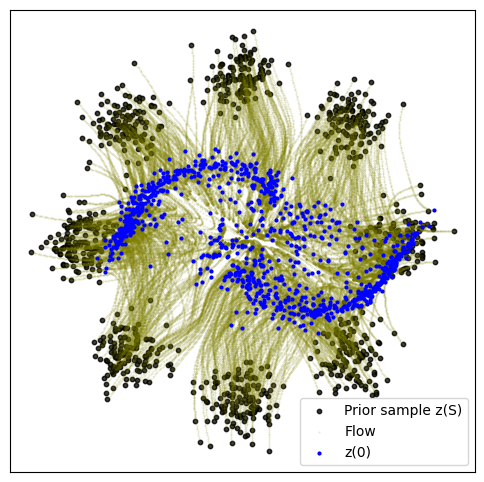

10000: loss 9.668 time 7.46


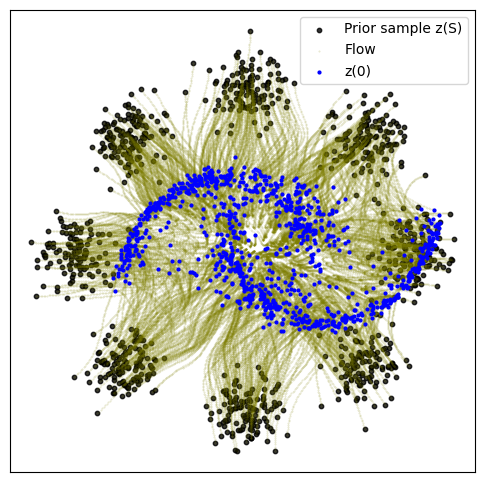

15000: loss 7.942 time 7.41


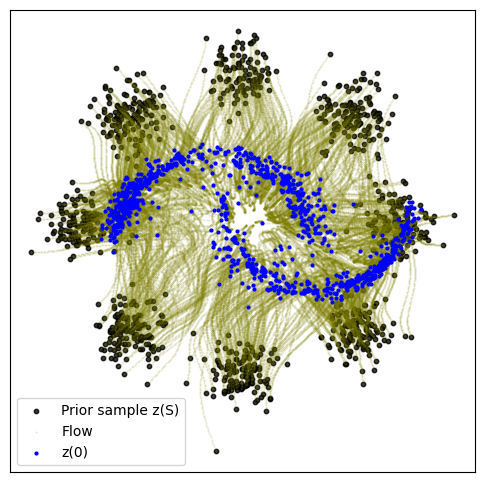

20000: loss 7.465 time 7.52


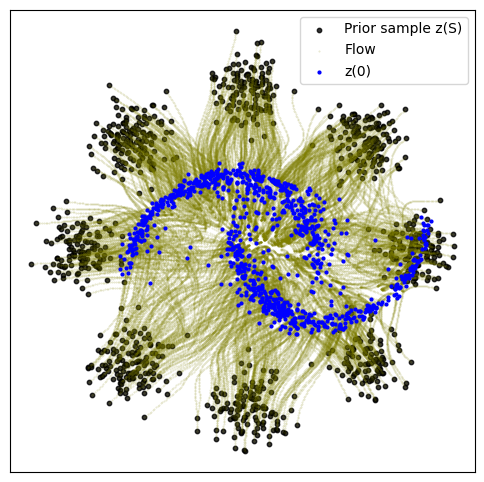

25000: loss 8.544 time 7.51


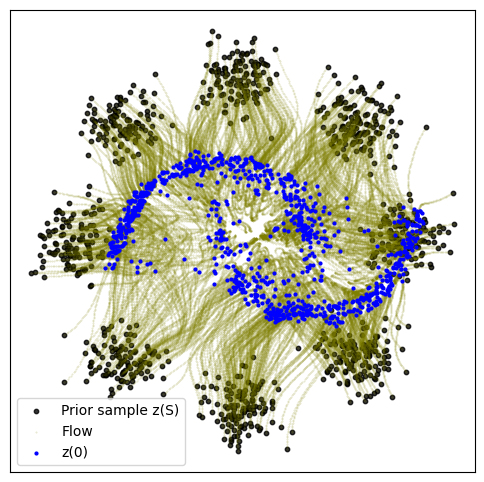

In [24]:
sigma = 0.01
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True)
optimizer = torch.optim.AdamW(model.parameters())

start = time.time()
epochs = 25000
for k in range(epochs):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size)
    x1 = sample_moons(batch_size)

    t = torch.rand(x0.shape[0]).type_as(x0)
    xt = sample_conditional_pt(x0, x1, t, sigma)
    ut = compute_conditional_vector_field(x0, x1)

    model_input = torch.cat([xt, t[:, None]], dim=-1)
    vt = model(model_input)
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            trajectory = node.trajectory(
                sample_8gaussians(1024),
                t_span= torch.linspace(0,1,100)
            )
            plot_trajectories(trajectory.cpu().numpy())

5000: loss 0.139 time 37.97


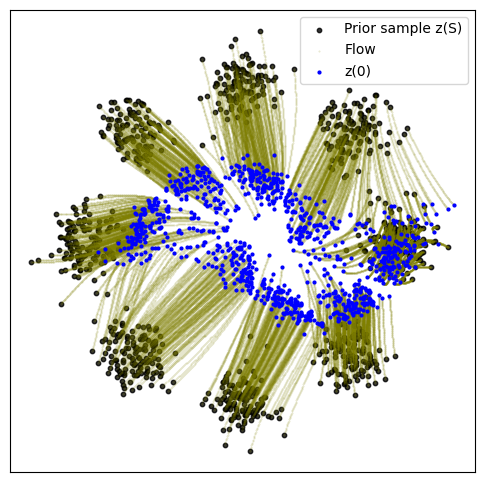

10000: loss 0.159 time 38.08


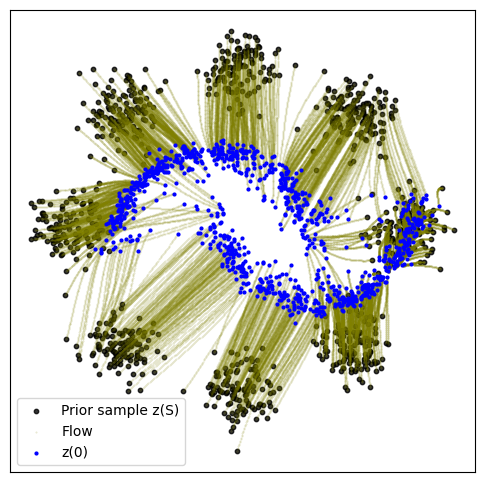

15000: loss 0.209 time 37.43


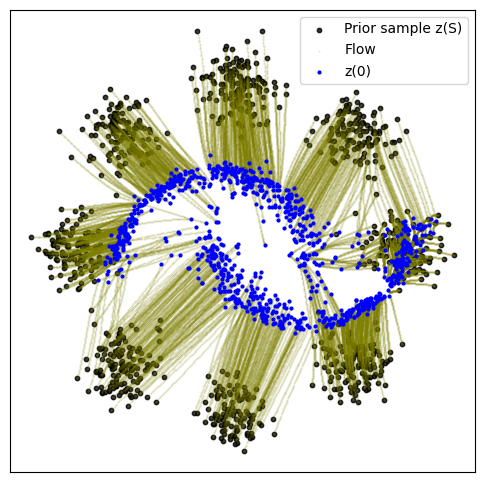

20000: loss 0.119 time 38.04


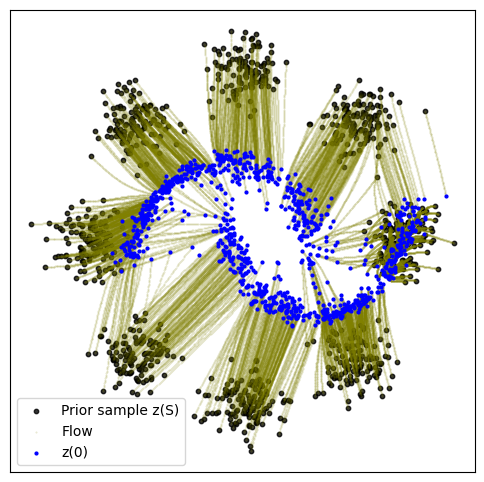

25000: loss 0.103 time 38.61


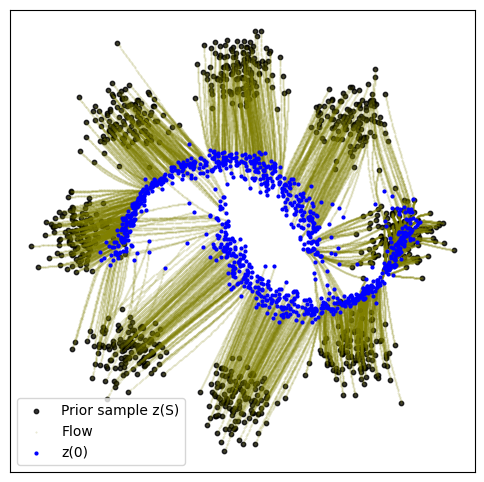

In [26]:
sigma = 0.01
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True)
optimizer = torch.optim.AdamW(model.parameters())
ot_sampler = OTPlanSampler(method="exact")



start = time.time()
epochs = 25000
for k in range(epochs):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size)
    x1 = sample_moons(batch_size)
    x0, x1 = ot_sampler.sample_plan(x0, x1)

    t = torch.rand(x0.shape[0]).type_as(x0)
    xt = sample_conditional_pt(x0, x1, t, sigma)
    ut = compute_conditional_vector_field(x0, x1)

    model_input = torch.cat([xt, t[:, None]], dim=-1)
    vt = model(model_input)
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            trajectory = node.trajectory(
                sample_8gaussians(1024),
                t_span= torch.linspace(0,1,100)
            )
            plot_trajectories(trajectory.cpu().numpy())